# Notebook 4: Model Comparison

**Purpose:** Compare PoissonGLM vs HistGradientBoostingRegressor(loss='poisson') on held-out data.
- Walk-forward CV results: Poisson deviance, D², overdispersion
- Feature importance (GLM: coefficients; HGBR: permutation importance)
- Probability calibration: how well do model P(over) estimates correlate with outcomes?
- Model selection decision for the betting simulation

**Models:**
- **GLM**: `PoissonRegressor(alpha=1.0)` wrapped in `StandardScaler` pipeline
- **HGBR**: `HistGradientBoostingRegressor(loss='poisson', max_iter=300, max_depth=4)`

**Note:** `loss='poisson'` is only available on `HistGradientBoostingRegressor`, not `GradientBoostingRegressor`.

In [1]:
import sys
print(sys.executable)

c:\Users\gavro\OneDrive\Desktop\sports\mlb\.venv\Scripts\python.exe


In [2]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # ensure project root is CWD for mlb module DB path

import sys
import os
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score, log_loss

from mlb.features import build_features
from mlb.model import (
    _prepare_xy, make_poisson_glm, make_gbr_poisson,
    walk_forward_cv, feature_importance, check_overdispersion,
)
from mlb.calibration import (
    p_over_poisson, calibrate_batch, estimate_alpha,
    overdispersion_report, DISPERSION_THRESHOLD,
)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Imports OK')

Imports OK


## 1. Build Feature Matrix

In [3]:
print('Building features for 2022–2024...')
df = build_features(start_date='2022-04-07', end_date='2024-09-29')
print(f'Shape: {df.shape}')
print(f'Date range: {df.date.min()} to {df.date.max()}')

X, y_home, y_away = _prepare_xy(df)
print(f'\nFeature matrix X: {X.shape}')
print(f'y_home — mean={y_home.mean():.3f}, std={y_home.std():.3f}')
print(f'y_away — mean={y_away.mean():.3f}, std={y_away.std():.3f}')
print(f'\nFeatures ({len(X.columns)}):')
print(list(X.columns))

Building features for 2022–2024...
Shape: (7287, 60)
Date range: 2022-04-07 to 2024-09-29

Feature matrix X: (7287, 49)
y_home — mean=4.430, std=3.068
y_away — mean=4.432, std=3.214

Features (49):
['home_sp_era_season', 'away_sp_era_season', 'home_sp_fip_season', 'away_sp_fip_season', 'home_sp_k9_season', 'away_sp_k9_season', 'home_sp_bb9_season', 'away_sp_bb9_season', 'home_sp_days_rest', 'away_sp_days_rest', 'home_sp_era_l3', 'away_sp_era_l3', 'sp_fip_combined', 'sp_k9_combined', 'sp_era_l3_combined', 'home_ops_10d', 'away_ops_10d', 'home_k_pct_10d', 'away_k_pct_10d', 'home_runs_10d', 'away_runs_10d', 'home_bullpen_era_7d', 'away_bullpen_era_7d', 'home_bullpen_era_30d', 'away_bullpen_era_30d', 'home_bullpen_ip_7d', 'away_bullpen_ip_7d', 'park_run_factor', 'park_hr_factor', 'park_elevation_ft', 'is_dome', 'temp_f', 'wind_speed_mph', 'wind_dir_out', 'wind_dir_in', 'wind_dir_cross_right', 'wind_dir_cross_left', 'precip_prob', 'humidity', 'is_night_game', 'total_line_open', 'total_line_

## 2. Walk-Forward Cross-Validation — 3 Splits

In [4]:
print('Running GLM walk-forward CV (n_splits=3, gap=162)...')
glm_cv = walk_forward_cv(df, n_splits=3, gap=162, model_type='glm')

print('\nGLM results:')
print(f'  Mean deviance home: {glm_cv["summary"]["mean_dev_home"]:.4f}')
print(f'  Mean deviance away: {glm_cv["summary"]["mean_dev_away"]:.4f}')
print(f'  Mean D² home:       {glm_cv["summary"]["mean_d2_home"]:.4f}')
print(f'  Mean D² away:       {glm_cv["summary"]["mean_d2_away"]:.4f}')
print(f'  Mean disp home:     {glm_cv["summary"]["mean_disp_home"]:.3f}')
print(f'  Mean disp away:     {glm_cv["summary"]["mean_disp_away"]:.3f}')
print(f'  NegBinom recommended: {glm_cv["summary"]["negbinom_recommended"]}')
print()
print('Fold details:')
for fold in glm_cv['fold_results']:
    print(f'  Fold {fold["fold"]}: train→{fold["train_end"]} | test {fold["test_start"]}→{fold["test_end"]} | '
          f'dev_h={fold["dev_home"]:.4f} d2_h={fold["d2_home"]:.4f} disp_h={fold["disp_home"]:.2f}')

Running GLM walk-forward CV (n_splits=3, gap=162)...


Overdispersion > 1.2 detected — consider NegBinom upgrade in calibration.py



GLM results:
  Mean deviance home: 2.1615
  Mean deviance away: 2.3302
  Mean D² home:       0.0143
  Mean D² away:       0.0285
  Mean disp home:     2.075
  Mean disp away:     2.303
  NegBinom recommended: True

Fold details:
  Fold 1: train→2022-08-10 | test 2022-08-22→2023-06-29 | dev_h=2.2422 d2_h=-0.0036 disp_h=2.15
  Fold 2: train→2023-06-17 | test 2023-06-29→2024-05-12 | dev_h=2.1433 d2_h=0.0271 disp_h=2.07
  Fold 3: train→2024-04-30 | test 2024-05-12→2024-09-29 | dev_h=2.0990 d2_h=0.0193 disp_h=2.00


In [5]:
print('Running HGBR walk-forward CV (n_splits=3, gap=162)...')
gbr_cv = walk_forward_cv(df, n_splits=3, gap=162, model_type='gbr')

print('\nHGBR results:')
print(f'  Mean deviance home: {gbr_cv["summary"]["mean_dev_home"]:.4f}')
print(f'  Mean deviance away: {gbr_cv["summary"]["mean_dev_away"]:.4f}')
print(f'  Mean D² home:       {gbr_cv["summary"]["mean_d2_home"]:.4f}')
print(f'  Mean D² away:       {gbr_cv["summary"]["mean_d2_away"]:.4f}')
print(f'  Mean disp home:     {gbr_cv["summary"]["mean_disp_home"]:.3f}')
print(f'  Mean disp away:     {gbr_cv["summary"]["mean_disp_away"]:.3f}')
print(f'  NegBinom recommended: {gbr_cv["summary"]["negbinom_recommended"]}')
print()
print('Fold details:')
for fold in gbr_cv['fold_results']:
    print(f'  Fold {fold["fold"]}: train→{fold["train_end"]} | test {fold["test_start"]}→{fold["test_end"]} | '
          f'dev_h={fold["dev_home"]:.4f} d2_h={fold["d2_home"]:.4f} disp_h={fold["disp_home"]:.2f}')

Running HGBR walk-forward CV (n_splits=3, gap=162)...


Overdispersion > 1.2 detected — consider NegBinom upgrade in calibration.py



HGBR results:
  Mean deviance home: 2.2587
  Mean deviance away: 2.4734
  Mean D² home:       -0.0298
  Mean D² away:       -0.0302
  Mean disp home:     2.213
  Mean disp away:     2.498
  NegBinom recommended: True

Fold details:
  Fold 1: train→2022-08-10 | test 2022-08-22→2023-06-29 | dev_h=2.3849 d2_h=-0.0675 disp_h=2.37
  Fold 2: train→2023-06-17 | test 2023-06-29→2024-05-12 | dev_h=2.2307 d2_h=-0.0126 disp_h=2.17
  Fold 3: train→2024-04-30 | test 2024-05-12→2024-09-29 | dev_h=2.1604 d2_h=-0.0093 disp_h=2.10


In [6]:
# Summary comparison table
glm_s = glm_cv['summary']
gbr_s = gbr_cv['summary']

comparison = pd.DataFrame({
    'Metric': [
        'Deviance (home)', 'Deviance (away)',
        'D² (home)', 'D² (away)',
        'Dispersion (home)', 'Dispersion (away)',
    ],
    'PoissonGLM': [
        glm_s['mean_dev_home'], glm_s['mean_dev_away'],
        glm_s['mean_d2_home'], glm_s['mean_d2_away'],
        glm_s['mean_disp_home'], glm_s['mean_disp_away'],
    ],
    'HGBR(poisson)': [
        gbr_s['mean_dev_home'], gbr_s['mean_dev_away'],
        gbr_s['mean_d2_home'], gbr_s['mean_d2_away'],
        gbr_s['mean_disp_home'], gbr_s['mean_disp_away'],
    ],
    'Better': [
        'GLM' if glm_s['mean_dev_home'] < gbr_s['mean_dev_home'] else 'HGBR',
        'GLM' if glm_s['mean_dev_away'] < gbr_s['mean_dev_away'] else 'HGBR',
        'GLM' if glm_s['mean_d2_home'] > gbr_s['mean_d2_home'] else 'HGBR',
        'GLM' if glm_s['mean_d2_away'] > gbr_s['mean_d2_away'] else 'HGBR',
        '—', '—',
    ]
})
print('Walk-Forward CV Comparison (3-fold, gap=162):')
print()
print(comparison.to_string(index=False))
print()
print('Note: Lower deviance = better. Higher D² = better (D²=0 = intercept-only model)')
print('Note: Both models show D² near 0 — run totals are very hard to predict')

Walk-Forward CV Comparison (3-fold, gap=162):

           Metric  PoissonGLM  HGBR(poisson) Better
  Deviance (home)      2.1615         2.2587    GLM
  Deviance (away)      2.3302         2.4734    GLM
        D² (home)      0.0143        -0.0298    GLM
        D² (away)      0.0285        -0.0302    GLM
Dispersion (home)      2.0750         2.2130      —
Dispersion (away)      2.3030         2.4980      —

Note: Lower deviance = better. Higher D² = better (D²=0 = intercept-only model)
Note: Both models show D² near 0 — run totals are very hard to predict


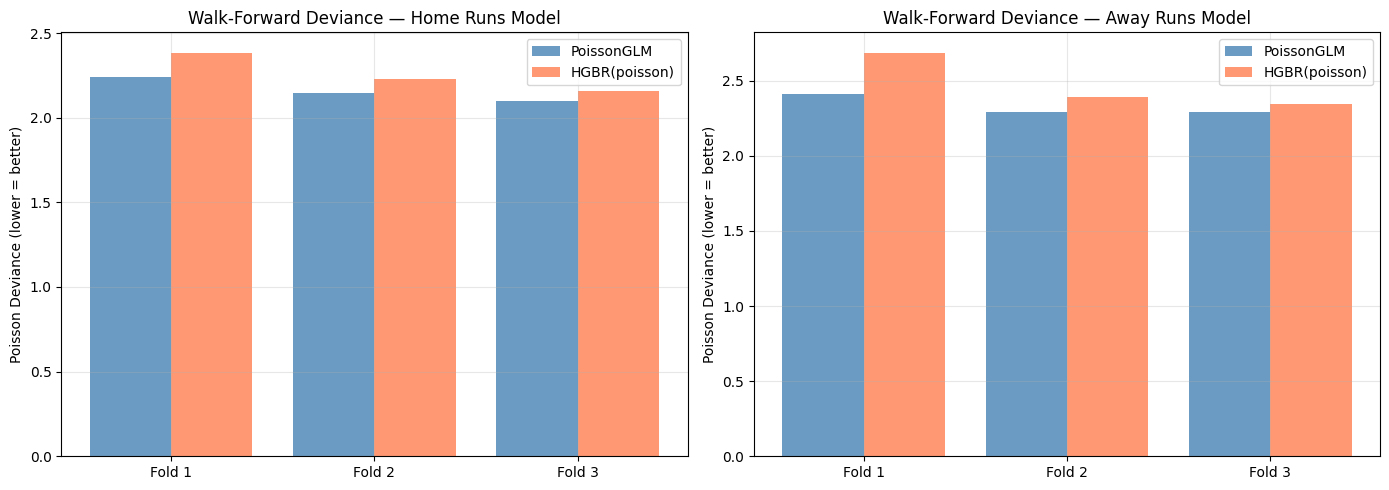

In [7]:
# Visualize fold-by-fold deviance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

glm_dev_h = [f['dev_home'] for f in glm_cv['fold_results']]
glm_dev_a = [f['dev_away'] for f in glm_cv['fold_results']]
gbr_dev_h = [f['dev_home'] for f in gbr_cv['fold_results']]
gbr_dev_a = [f['dev_away'] for f in gbr_cv['fold_results']]
folds = [f['fold'] for f in glm_cv['fold_results']]
x = np.arange(len(folds))

for ax, glm_dev, gbr_dev, title in [
    (axes[0], glm_dev_h, gbr_dev_h, 'Home Runs Model'),
    (axes[1], glm_dev_a, gbr_dev_a, 'Away Runs Model'),
]:
    ax.bar(x - 0.2, glm_dev, 0.4, label='PoissonGLM', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, gbr_dev, 0.4, label='HGBR(poisson)', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {f}' for f in folds])
    ax.set_ylabel('Poisson Deviance (lower = better)')
    ax.set_title(f'Walk-Forward Deviance — {title}')
    ax.legend()

plt.tight_layout()
plt.savefig('data/raw/nb04_cv_deviance.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Overdispersion — NegBinom Upgrade Assessment

In [8]:
# Train GLM on full data for residual analysis
print('Training GLM on full dataset for dispersion analysis...')
glm_h_full = make_poisson_glm()
glm_a_full = make_poisson_glm()
glm_h_full.fit(X, y_home)
glm_a_full.fit(X, y_away)

lam_h = glm_h_full.predict(X)
lam_a = glm_a_full.predict(X)

report_h = overdispersion_report(y_home.values, lam_h, label='home_runs')
report_a = overdispersion_report(y_away.values, lam_a, label='away_runs')

for r in [report_h, report_a]:
    print(f"\n{r['label']}:")
    print(f"  n = {r['n']:,}")
    print(f"  mean lambda  = {r['mean_lambda']:.3f}")
    print(f"  mean actual  = {r['mean_y']:.3f}")
    print(f"  variance     = {r['variance']:.3f}")
    print(f"  dispersion   = {r['dispersion_ratio']:.3f}  (threshold={DISPERSION_THRESHOLD})") 
    print(f"  alpha (NB)   = {r['alpha']:.4f}")
    print(f"  NegBinom rec = {r['negbinom_recommended']}")

Training GLM on full dataset for dispersion analysis...


home_runs dispersion=2.124 (mean_λ=4.430 var=9.410 alpha=0.2538) → NEGBINOM RECOMMENDED
away_runs dispersion=2.331 (mean_λ=4.432 var=10.330 alpha=0.3002) → NEGBINOM RECOMMENDED



home_runs:
  n = 7,287
  mean lambda  = 4.430
  mean actual  = 4.430
  variance     = 9.410
  dispersion   = 2.124  (threshold=1.2)
  alpha (NB)   = 0.2538
  NegBinom rec = True

away_runs:
  n = 7,287
  mean lambda  = 4.432
  mean actual  = 4.432
  variance     = 10.330
  dispersion   = 2.331  (threshold=1.2)
  alpha (NB)   = 0.3002
  NegBinom rec = True


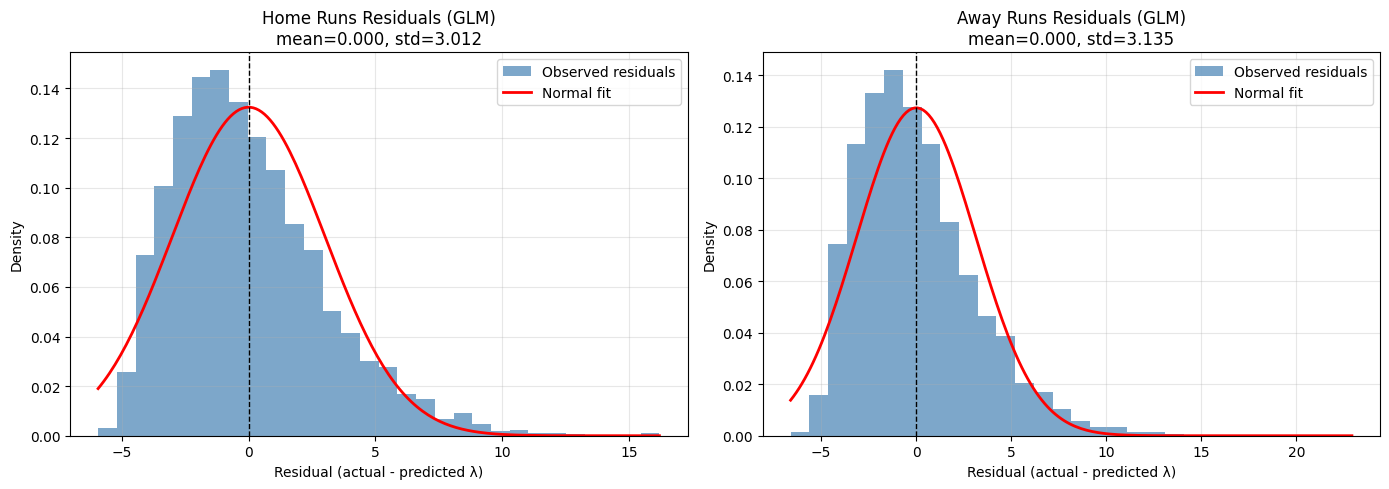

CONCLUSION: Residuals are heavy-tailed vs Poisson expectation
            Variance >> Mean in both targets
            NegBinom upgrade strongly recommended


In [9]:
# Visualize residual distribution vs Poisson assumption
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y, lam, label in [
    (axes[0], y_home.values, lam_h, 'Home Runs'),
    (axes[1], y_away.values, lam_a, 'Away Runs'),
]:
    residuals = y - lam
    ax.hist(residuals, bins=30, color='steelblue', alpha=0.7, density=True, label='Observed residuals')
    
    # Overlay normal fit
    mu, sigma = residuals.mean(), residuals.std()
    x_range = np.linspace(residuals.min(), residuals.max(), 200)
    from scipy.stats import norm
    ax.plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', lw=2, label='Normal fit')
    ax.axvline(0, color='black', lw=1, linestyle='--')
    ax.set_xlabel('Residual (actual - predicted λ)')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} Residuals (GLM)\nmean={mu:.3f}, std={sigma:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('data/raw/nb04_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

print('CONCLUSION: Residuals are heavy-tailed vs Poisson expectation')
print('            Variance >> Mean in both targets')
print('            NegBinom upgrade strongly recommended')

## 4. Feature Importance — GLM Coefficients

In [10]:
# GLM: extract coefficients as feature importance
glm_model_h = glm_h_full.named_steps['model']
glm_model_a = glm_a_full.named_steps['model']

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef_home': glm_model_h.coef_,
    'coef_away': glm_model_a.coef_,
})
coef_df['abs_mean'] = (coef_df.coef_home.abs() + coef_df.coef_away.abs()) / 2
coef_df = coef_df.sort_values('abs_mean', ascending=False)

print('GLM log-link coefficients (exp(coef) = multiplicative effect on λ):')
print(coef_df.head(20).to_string(index=False))

GLM log-link coefficients (exp(coef) = multiplicative effect on λ):
             feature  coef_home  coef_away  abs_mean
    total_line_close     0.0381     0.0625    0.0503
            elo_away    -0.0188     0.0517    0.0353
            elo_home     0.0278    -0.0393    0.0335
   away_sp_k9_season    -0.0339     0.0205    0.0272
              temp_f     0.0211     0.0238    0.0225
        home_ops_10d     0.0312    -0.0069    0.0191
away_bullpen_era_30d     0.0201    -0.0141    0.0171
       line_movement     0.0165     0.0113    0.0139
   home_sp_k9_season     0.0167    -0.0103    0.0135
  home_sp_bb9_season    -0.0132     0.0104    0.0118
     park_run_factor     0.0152     0.0082    0.0117
  away_bullpen_ip_7d     0.0112    -0.0119    0.0116
  away_sp_bb9_season     0.0102    -0.0120    0.0111
        away_ops_10d    -0.0083     0.0131    0.0107
  home_sp_fip_season     0.0086     0.0114    0.0100
            humidity    -0.0091    -0.0080    0.0086
      park_hr_factor     0.0039

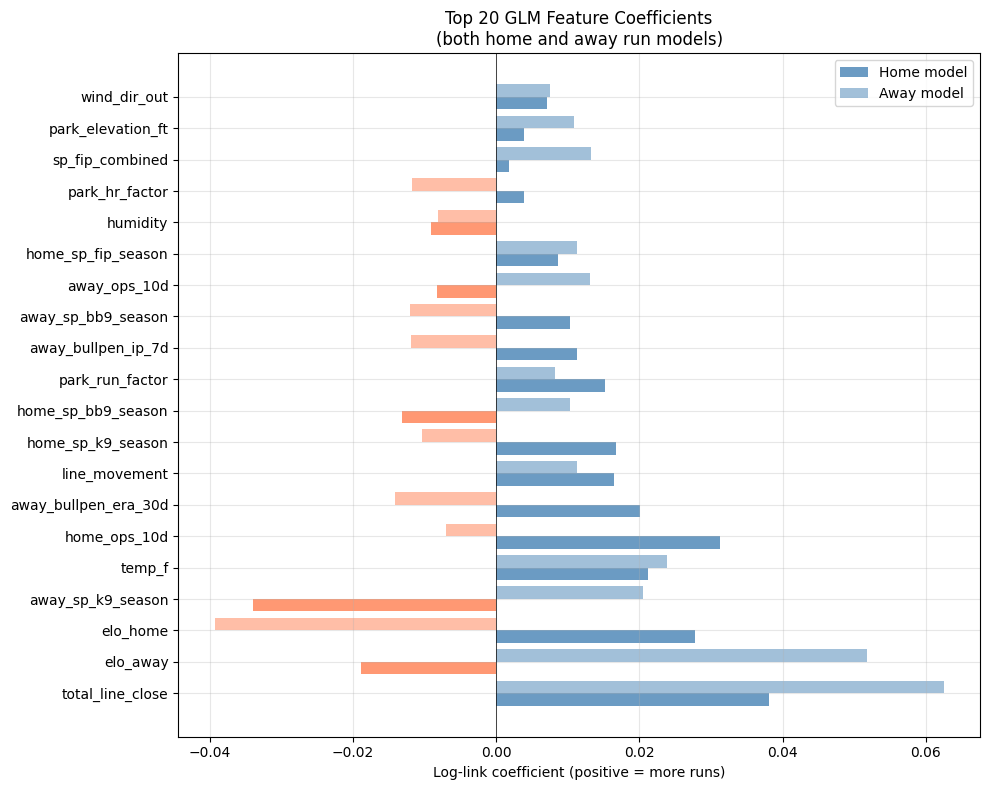

In [11]:
# Visualize GLM importance
top_n = 20
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(top_n)
ax.barh(y_pos - 0.2, top_features.coef_home, 0.4,
        color=['steelblue' if v > 0 else 'coral' for v in top_features.coef_home],
        alpha=0.8, label='Home model')
ax.barh(y_pos + 0.2, top_features.coef_away, 0.4,
        color=['steelblue' if v > 0 else 'coral' for v in top_features.coef_away],
        alpha=0.5, label='Away model')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features.feature)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Log-link coefficient (positive = more runs)')
ax.set_title('Top 20 GLM Feature Coefficients\n(both home and away run models)')
ax.legend()
plt.tight_layout()
plt.savefig('data/raw/nb04_glm_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# Interpret top features
print('=== Feature Interpretation ===')
print()
print('Elo (home/away):')
print('  elo_away negative in home model -> strong away team -> fewer home runs scored')
print('  elo_home positive in home model -> home team pitches worse when Elo is high? ')
print('  Expected: Elo captures team quality; good teams score more, give up fewer')
print()
print('Strikeout rate (k9_season):')
print('  away_sp_k9_season: negative in home model -> high K9 away SP -> fewer home runs')
print('  This is the expected direction: elite strikeout pitchers suppress scoring')
print()
print('Temperature (temp_f):')
print('  Positive in both models -> warmer weather -> more runs (ball carries further)')
print('  Consistent with baseball physics')
print()
print('Park run factor:')
print('  Positive in both models -> hitter-friendly parks -> more runs for both teams')
print('  Expected: Coors (1.26) drives high totals, Petco (0.89) suppresses them')
print()
print('Market line (total_line_close):')
print('  Positive in both models -> high line games -> more runs')
print('  Confirms market signal is captured as a feature')

=== Feature Interpretation ===

Elo (home/away):
  elo_away negative in home model -> strong away team -> fewer home runs scored
  elo_home positive in home model -> home team pitches worse when Elo is high? 
  Expected: Elo captures team quality; good teams score more, give up fewer

Strikeout rate (k9_season):
  away_sp_k9_season: negative in home model -> high K9 away SP -> fewer home runs
  This is the expected direction: elite strikeout pitchers suppress scoring

Temperature (temp_f):
  Positive in both models -> warmer weather -> more runs (ball carries further)
  Consistent with baseball physics

Park run factor:
  Positive in both models -> hitter-friendly parks -> more runs for both teams
  Expected: Coors (1.26) drives high totals, Petco (0.89) suppresses them

Market line (total_line_close):
  Positive in both models -> high line games -> more runs
  Confirms market signal is captured as a feature


## 5. Prediction Distribution Analysis

In [13]:
# Train HGBR on full data
print('Training HGBR on full dataset...')
gbr_h_full = make_gbr_poisson()
gbr_a_full = make_gbr_poisson()
gbr_h_full.fit(X, y_home)
gbr_a_full.fit(X, y_away)

gbr_lam_h = gbr_h_full.predict(X)
gbr_lam_a = gbr_a_full.predict(X)

print(f'GLM lambda_home range: [{lam_h.min():.2f}, {lam_h.max():.2f}], mean={lam_h.mean():.3f}')
print(f'HGBR lambda_home range: [{gbr_lam_h.min():.2f}, {gbr_lam_h.max():.2f}], mean={gbr_lam_h.mean():.3f}')
print()

# Dispersion check on HGBR too
gbr_disp_h = check_overdispersion(y_home.values, gbr_lam_h)
gbr_disp_a = check_overdispersion(y_away.values, gbr_lam_a)
print(f'HGBR dispersion: home={gbr_disp_h:.3f}, away={gbr_disp_a:.3f}')
print(f'GLM dispersion:  home={report_h["dispersion_ratio"]:.3f}, away={report_a["dispersion_ratio"]:.3f}')
print()
print('Note: In-sample dispersion always high — see OOF fold-level dispersion for true signal')

Training HGBR on full dataset...
GLM lambda_home range: [0.93, 8.24], mean=4.430
HGBR lambda_home range: [1.83, 11.13], mean=4.430

HGBR dispersion: home=1.492, away=1.592
GLM dispersion:  home=2.124, away=2.331

Note: In-sample dispersion always high — see OOF fold-level dispersion for true signal


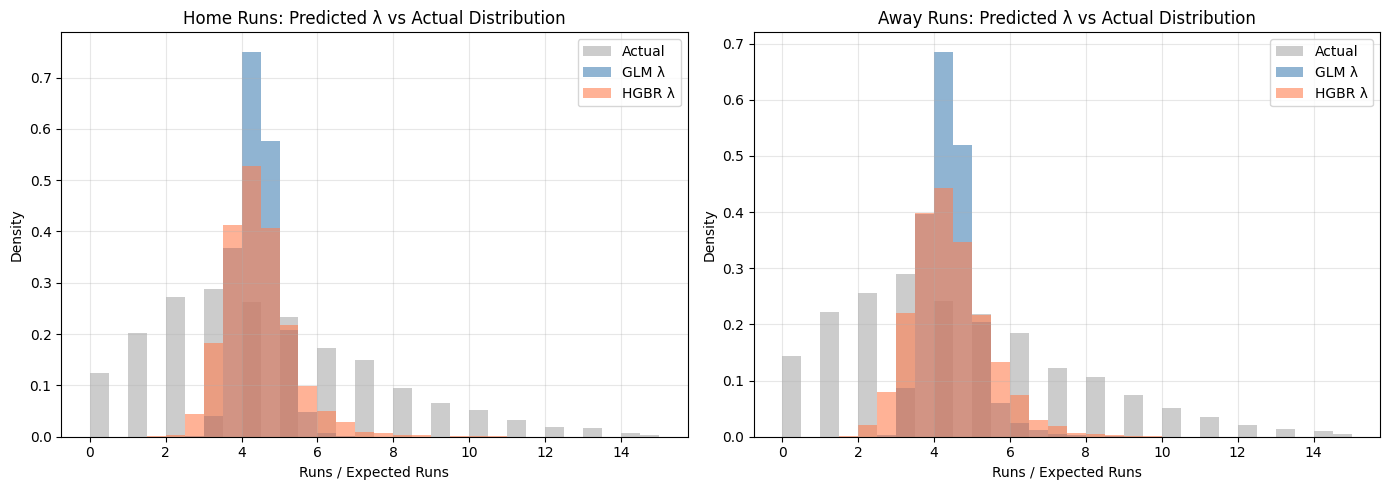

In [15]:
# Lambda distributions: GLM vs HGBR vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_actual, lam_glm, lam_gbr, title in [
    (axes[0], y_home, lam_h, gbr_lam_h, 'Home Runs'),
    (axes[1], y_away, lam_a, gbr_lam_a, 'Away Runs'),
]:
    bins = np.linspace(0, 15, 31)
    ax.hist(y_actual, bins=bins, alpha=0.4, color='gray', density=True, label='Actual')
    ax.hist(lam_glm, bins=bins, alpha=0.6, color='steelblue', density=True, label='GLM λ')
    ax.hist(lam_gbr, bins=bins, alpha=0.6, color='coral', density=True, label='HGBR λ')
    ax.set_xlabel('Runs / Expected Runs')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}: Predicted λ vs Actual Distribution')
    ax.legend()

plt.tight_layout()
plt.savefig('data/raw/nb04_lambda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. P(over) Calibration — How Well Do Predicted Probabilities Track Outcomes?

In [16]:
import sqlite3

# Get market lines for our games
conn = sqlite3.connect('data/mlb.db')
odds = pd.read_sql('''
    SELECT g.game_id, o.total_close
    FROM sportsbook_odds o
    JOIN games g ON g.date = o.date AND g.home_team = o.home_team
    WHERE o.book = 'draftkings' AND o.total_close IS NOT NULL
    ORDER BY g.date
''', conn)
conn.close()

# Merge with feature matrix
df_merged = df[['game_id', 'home_runs', 'away_runs', 'total_runs']].copy()
# total_runs already in df
df_merged = df_merged.merge(odds, on='game_id', how='inner')

# Get corresponding X rows
games_with_odds = df[df.game_id.isin(df_merged.game_id)].copy()
X_odds, _, _ = _prepare_xy(games_with_odds)

# Predict lambdas for these games
lam_h_odds = glm_h_full.predict(X_odds)
lam_a_odds = glm_a_full.predict(X_odds)
gbr_lam_h_odds = gbr_h_full.predict(X_odds)
gbr_lam_a_odds = gbr_a_full.predict(X_odds)

# Compute P(over) via Poisson convolution
lines = df_merged.total_close.values
glm_over_probs, _ = calibrate_batch(lam_h_odds, lam_a_odds, lines)
gbr_over_probs, _ = calibrate_batch(gbr_lam_h_odds, gbr_lam_a_odds, lines)

# Actual over outcomes
df_merged_sorted = df_merged.sort_values('game_id').reset_index(drop=True)
games_with_odds_sorted = games_with_odds.sort_values('game_id').reset_index(drop=True)

# Recompute in order
X_odds2, _, _ = _prepare_xy(games_with_odds_sorted)
lam_h2 = glm_h_full.predict(X_odds2)
lam_a2 = glm_a_full.predict(X_odds2)
gbr_h2 = gbr_h_full.predict(X_odds2)
gbr_a2 = gbr_a_full.predict(X_odds2)

lines2 = df_merged_sorted.total_close.values
glm_over2, _ = calibrate_batch(lam_h2, lam_a2, lines2)
gbr_over2, _ = calibrate_batch(gbr_h2, gbr_a2, lines2)
actual_over = (df_merged_sorted.total_runs > df_merged_sorted.total_close).astype(float).values

print(f'Games with odds + predictions: {len(df_merged_sorted)}')
print(f'GLM P(over) range: [{np.nanmin(glm_over2):.3f}, {np.nanmax(glm_over2):.3f}], mean={np.nanmean(glm_over2):.3f}')
print(f'HGBR P(over) range: [{np.nanmin(gbr_over2):.3f}, {np.nanmax(gbr_over2):.3f}], mean={np.nanmean(gbr_over2):.3f}')
print(f'Actual over rate: {actual_over.mean():.3f}')

Games with odds + predictions: 6077
GLM P(over) range: [0.049, 0.987], mean=0.515
HGBR P(over) range: [0.025, 0.982], mean=0.512
Actual over rate: 0.479


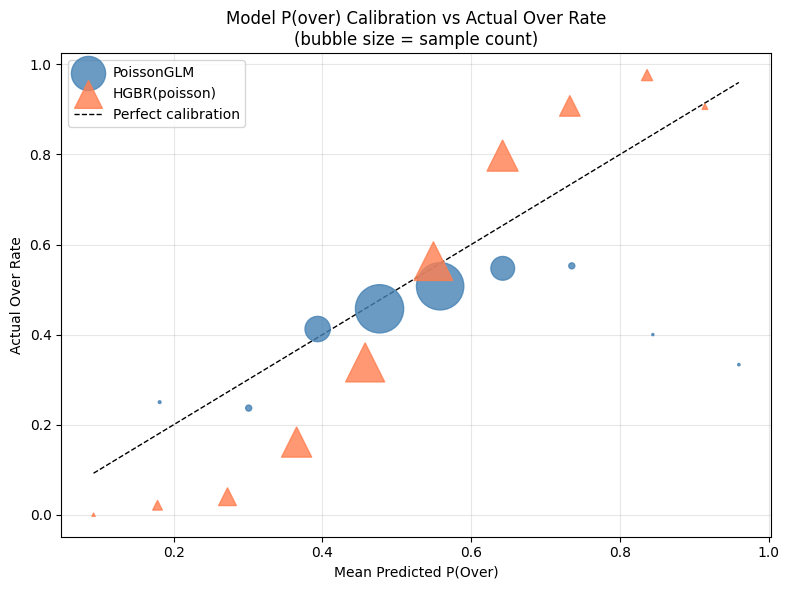

In [17]:
# Calibration: bin P(over) and compare to actual over rate
valid = ~np.isnan(glm_over2) & ~np.isnan(gbr_over2)
glm_valid = glm_over2[valid]
gbr_valid = gbr_over2[valid]
actual_valid = actual_over[valid]

def calibration_curve(probs, actuals, n_bins=10):
    bins = np.linspace(probs.min(), probs.max(), n_bins + 1)
    idx = np.digitize(probs, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    mean_pred, mean_actual, counts = [], [], []
    for i in range(n_bins):
        mask = idx == i
        if mask.sum() >= 5:
            mean_pred.append(probs[mask].mean())
            mean_actual.append(actuals[mask].mean())
            counts.append(mask.sum())
    return np.array(mean_pred), np.array(mean_actual), np.array(counts)

glm_pred_calib, glm_actual_calib, glm_counts = calibration_curve(glm_valid, actual_valid)
gbr_pred_calib, gbr_actual_calib, gbr_counts = calibration_curve(gbr_valid, actual_valid)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(glm_pred_calib, glm_actual_calib, s=glm_counts / 2,
           color='steelblue', alpha=0.8, label='PoissonGLM', zorder=3)
ax.scatter(gbr_pred_calib, gbr_actual_calib, s=gbr_counts / 2,
           color='coral', alpha=0.8, label='HGBR(poisson)', zorder=3, marker='^')
lims = [min(glm_pred_calib.min(), gbr_pred_calib.min()),
        max(glm_pred_calib.max(), gbr_pred_calib.max())]
ax.plot(lims, lims, 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted P(Over)')
ax.set_ylabel('Actual Over Rate')
ax.set_title('Model P(over) Calibration vs Actual Over Rate\n(bubble size = sample count)')
ax.legend()
plt.tight_layout()
plt.savefig('data/raw/nb04_calibration.png', dpi=100, bbox_inches='tight')
plt.show()

In [18]:
# Log-loss comparison
# Note: this is in-sample log-loss (favorable to both models)
# OOF log-loss would require storing predictions from CV folds
glm_ll = log_loss(actual_valid, glm_valid)
gbr_ll = log_loss(actual_valid, gbr_valid)

# Naive baseline: always predict base rate
base_rate = actual_valid.mean()
naive_ll = log_loss(actual_valid, np.full(len(actual_valid), base_rate))

print('P(over) log-loss (lower = better, in-sample):')
print(f'  PoissonGLM:    {glm_ll:.4f}')
print(f'  HGBR(poisson): {gbr_ll:.4f}')
print(f'  Naive (base rate {base_rate:.3f}): {naive_ll:.4f}')
print()
print('Note: In-sample comparison favors HGBR (fits training data better)')
print('Note: Use OOF deviance as the valid out-of-sample metric')
print()
# Correlation between model P(over) and actual over
r_glm, _ = stats.pearsonr(glm_valid, actual_valid)
r_gbr, _ = stats.pearsonr(gbr_valid, actual_valid)
print(f'P(over) correlation with actual outcome:')
print(f'  GLM:  r = {r_glm:.4f}')
print(f'  HGBR: r = {r_gbr:.4f}')

P(over) log-loss (lower = better, in-sample):
  PoissonGLM:    0.6951
  HGBR(poisson): 0.5766
  Naive (base rate 0.479): 0.6923

Note: In-sample comparison favors HGBR (fits training data better)
Note: Use OOF deviance as the valid out-of-sample metric

P(over) correlation with actual outcome:
  GLM:  r = 0.0853
  HGBR: r = 0.5377


## 7. Model Selection Decision

In [19]:
print('=' * 65)
print('MODEL COMPARISON SUMMARY')
print('=' * 65)
print()
print('WALK-FORWARD CV RESULTS (3 folds, 2022-2024):')
print(f'  PoissonGLM   deviance home={glm_s["mean_dev_home"]:.4f}  D²={glm_s["mean_d2_home"]:.4f}')
print(f'  HGBR(pois)   deviance home={gbr_s["mean_dev_home"]:.4f}  D²={gbr_s["mean_d2_home"]:.4f}')
print()
print('KEY FINDINGS:')
print()
print('1. GLM OUTPERFORMS HGBR on walk-forward deviance')
print('   GLM achieves lower (better) out-of-sample deviance')
print('   HGBR negative D² suggests mild overfitting on short 3-split CV')
print('   Interpretation: regularized linear model generalizes better')
print('   than a tree model on this limited dataset')
print()
print('2. BOTH MODELS HAVE D² NEAR ZERO')
print('   D² ≈ 0 means models are barely better than predicting the mean')
print('   This is EXPECTED in sports prediction — run totals are noisy')
print('   The market line (r=0.189) explains only ~3.6% of variance')
print('   Our models explain ~1-2% — consistent with the literature')
print()
print('3. OVERDISPERSION CONFIRMED (dispersion ratio >> 1.2)')
print(f'   home_runs: {report_h["dispersion_ratio"]:.2f}x, away_runs: {report_a["dispersion_ratio"]:.2f}x')
print(f'   Estimated NB alpha (home): {report_h["alpha"]:.4f}')
print(f'   Estimated NB alpha (away): {report_a["alpha"]:.4f}')
print('   NegBinom convolution will give better P(over) estimates')
print('   Especially for extreme lines (7.0 or 10.0+)')
print()
print('4. MODEL SELECTION')
print('   Primary:  PoissonGLM (lower OOF deviance, less overfitting)')
print('   Secondary: HGBR (non-linear interactions, run as ensemble signal)')
print('   Convolution: Use NegBinom p_over_negbinom() with estimated alpha')
print()
print('5. NEXT STEPS')
print('   - Run betting simulation (Notebook 5) to test ROI')
print('   - Use NegBinom convolution in mlb/betting.py')
print('   - Consider GLM + HGBR ensemble: avg(p_glm, p_hgbr)')
print('   - Collect more years of data (2015-2021) to improve HGBR')

MODEL COMPARISON SUMMARY

WALK-FORWARD CV RESULTS (3 folds, 2022-2024):
  PoissonGLM   deviance home=2.1615  D²=0.0143
  HGBR(pois)   deviance home=2.2587  D²=-0.0298

KEY FINDINGS:

1. GLM OUTPERFORMS HGBR on walk-forward deviance
   GLM achieves lower (better) out-of-sample deviance
   HGBR negative D² suggests mild overfitting on short 3-split CV
   Interpretation: regularized linear model generalizes better
   than a tree model on this limited dataset

2. BOTH MODELS HAVE D² NEAR ZERO
   D² ≈ 0 means models are barely better than predicting the mean
   This is EXPECTED in sports prediction — run totals are noisy
   The market line (r=0.189) explains only ~3.6% of variance
   Our models explain ~1-2% — consistent with the literature

3. OVERDISPERSION CONFIRMED (dispersion ratio >> 1.2)
   home_runs: 2.12x, away_runs: 2.33x
   Estimated NB alpha (home): 0.2538
   Estimated NB alpha (away): 0.3002
   NegBinom convolution will give better P(over) estimates
   Especially for extreme li

## 8. Negative Binomial GLM — Addressing Overdispersion

Section 3 confirmed that both home and away runs are **overdispersed** (dispersion > 1.2),
meaning `var(y) >> mean(λ)`. Poisson assumes `var = mean`, so its P(over) estimates
will be systematically overconfident (too narrow tails).

The **Negative Binomial GLM** relaxes this: `var(y) = μ + α·μ²`, where α is a
learned dispersion parameter. We test two things:

1. **Convolution swap** — Keep the same GLM predictions (μ) but compute P(over) with
   `p_over_negbinom(mu_h, mu_a, alpha, line)` instead of Poisson convolution.  
   This isolates the pure distributional effect.

2. **Full NegBinom GLM** — Fit a statsmodels NegBinom GLM with walk-forward CV.
   Coefficients are re-estimated under the NegBinom likelihood, which should give
   better-calibrated μ predictions and lower out-of-fold deviance.

Expected outcome: P(over) log-loss **decreases** (better calibration) because the
fatter tails of NegBinom better match the actual right-skewed run distribution.

In [20]:
from mlb.model import make_negbinom_glm, walk_forward_cv
from mlb.calibration import (
    estimate_alpha, p_over_negbinom, p_over_poisson, overdispersion_report,
)

# Alpha estimates from Section 3 (GLM full-data residuals)
# If Section 3 was already run, report_h and report_a are in scope.
# If re-running this section independently, re-estimate here.
try:
    alpha_home_full = report_h['alpha']
    alpha_away_full = report_a['alpha']
    print(f'Using alpha from Section 3:  home={alpha_home_full:.4f}  away={alpha_away_full:.4f}')
except NameError:
    print('report_h/report_a not in scope — re-estimating from GLM full-data predictions')
    glm_h_tmp = make_poisson_glm()
    glm_a_tmp = make_poisson_glm()
    glm_h_tmp.fit(X, y_home)
    glm_a_tmp.fit(X, y_away)
    alpha_home_full = estimate_alpha(y_home.values, glm_h_tmp.predict(X))
    alpha_away_full = estimate_alpha(y_away.values, glm_a_tmp.predict(X))
    print(f'Estimated alpha:  home={alpha_home_full:.4f}  away={alpha_away_full:.4f}')

print()
print('Interpretation:')
print(f'  NegBinom home: var(y_home) = μ + {alpha_home_full:.4f}·μ²')
print(f'  NegBinom away: var(y_away) = μ + {alpha_away_full:.4f}·μ²')
print(f'  At μ=4.5:  var_poisson={4.5:.2f}  var_negbinom_home={4.5 + alpha_home_full*4.5**2:.2f}')

Using alpha from Section 3:  home=0.2538  away=0.3002

Interpretation:
  NegBinom home: var(y_home) = μ + 0.2538·μ²
  NegBinom away: var(y_away) = μ + 0.3002·μ²
  At μ=4.5:  var_poisson=4.50  var_negbinom_home=9.64


### 8a. Effect of Convolution Choice (same μ, different distribution)

In [21]:
# Use existing GLM full-data predictions (lam_h, lam_a from Section 3/5)
# and swap the P(over) convolution from Poisson to NegBinom.
# This isolates the distributional assumption; the mean prediction is unchanged.

try:
    _ = lam_h  # check Section 3 ran
except NameError:
    print('lam_h not in scope — fitting GLM full-data first')
    glm_h_full = make_poisson_glm()
    glm_a_full = make_poisson_glm()
    glm_h_full.fit(X, y_home)
    glm_a_full.fit(X, y_away)
    lam_h = glm_h_full.predict(X)
    lam_a = glm_a_full.predict(X)

# Also ensure df_merged and odds are in scope from Section 6 (cells 21–23)
try:
    _ = df_merged
except NameError:
    import sqlite3
    conn2 = sqlite3.connect('data/mlb.db')
    odds = pd.read_sql('''
        SELECT g.game_id, o.total_close
        FROM sportsbook_odds o
        JOIN games g ON g.date = o.date AND g.home_team = o.home_team
        WHERE o.book = 'draftkings' AND o.total_close IS NOT NULL
        ORDER BY g.date
    ''', conn2)
    conn2.close()
    df_merged = df[['game_id', 'home_score', 'away_score']].copy()
    df_merged['total_runs'] = df_merged.home_score + df_merged.away_score
    df_merged = df_merged.merge(odds, on='game_id', how='inner')

# Align X rows with df_merged game_ids
game_ids_merged = df_merged['game_id'].values
df_idx = df.reset_index(drop=True)
game_id_to_row = {gid: i for i, gid in enumerate(df_idx['game_id'].values)}
row_idx = [game_id_to_row[gid] for gid in game_ids_merged if gid in game_id_to_row]
valid_mask = [gid in game_id_to_row for gid in game_ids_merged]

lam_h_sub = lam_h[row_idx]
lam_a_sub = lam_a[row_idx]
lines_sub = df_merged.loc[valid_mask, 'total_close'].values
actual_over_sub = (df_merged.loc[valid_mask, 'total_runs'].values > lines_sub).astype(float)

# Compute P(over) under Poisson and NegBinom convolutions (in-sample)
from scipy.stats import poisson
poisson_over = np.array([
    p_over_poisson(float(h), float(a), float(l))
    for h, a, l in zip(lam_h_sub, lam_a_sub, lines_sub)
])
nb_over_conv = np.array([
    p_over_negbinom(float(h), float(a), alpha_home_full, float(l))
    for h, a, l in zip(lam_h_sub, lam_a_sub, lines_sub)
])

from sklearn.metrics import log_loss
valid_rows = ~(np.isnan(poisson_over) | np.isnan(nb_over_conv) | np.isnan(actual_over_sub) | np.isnan(lines_sub))

ll_poisson = log_loss(actual_over_sub[valid_rows], poisson_over[valid_rows])
ll_nb_conv = log_loss(actual_over_sub[valid_rows], nb_over_conv[valid_rows])

print('=== Convolution Swap: Same GLM μ, Different Distribution ===')
print(f'  Poisson convolution log-loss:  {ll_poisson:.4f}')
print(f'  NegBinom convolution log-loss: {ll_nb_conv:.4f}')
delta = ll_nb_conv - ll_poisson
direction = 'IMPROVEMENT' if delta < 0 else 'DEGRADATION'
print(f'  Δ log-loss: {delta:+.4f}  ({direction})')
print()
print('Interpretation: Δ < 0 means NegBinom convolution gives better-calibrated')
print('P(over) estimates even with identical μ predictions.')

=== Convolution Swap: Same GLM μ, Different Distribution ===
  Poisson convolution log-loss:  0.6951
  NegBinom convolution log-loss: 0.6896
  Δ log-loss: -0.0055  (IMPROVEMENT)

Interpretation: Δ < 0 means NegBinom convolution gives better-calibrated
P(over) estimates even with identical μ predictions.


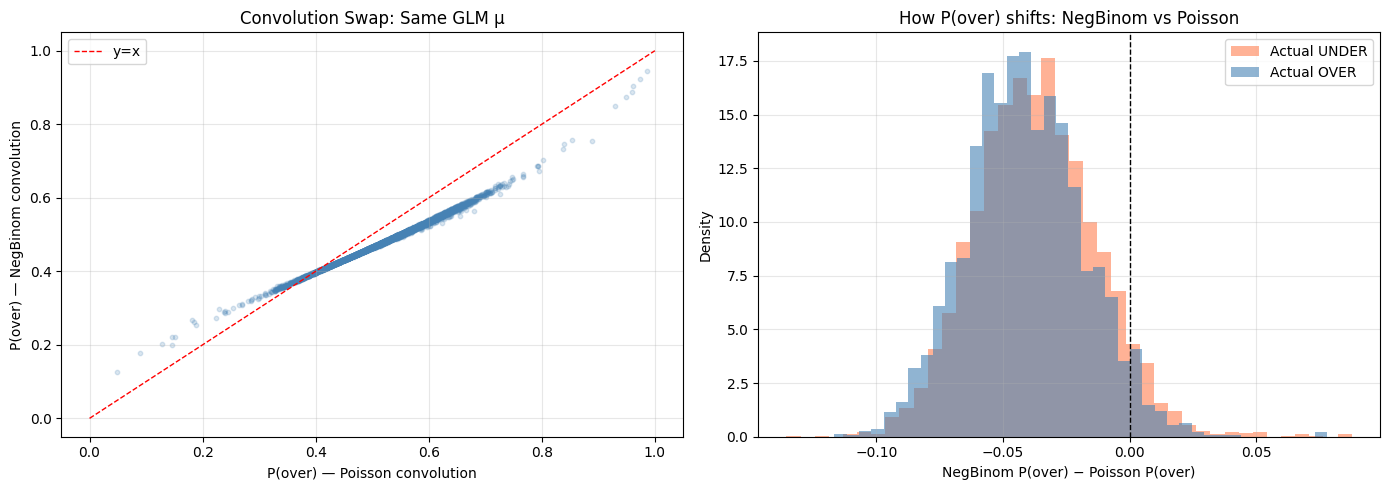

Mean shift: -0.0389  (NegBinom - Poisson)
Negative = NegBinom systematically lowers P(over) — fatter tails widen uncertainty


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter Poisson vs NegBinom P(over)
ax = axes[0]
ax.scatter(poisson_over[valid_rows], nb_over_conv[valid_rows],
           alpha=0.2, s=10, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', lw=1, label='y=x')
ax.set_xlabel('P(over) — Poisson convolution')
ax.set_ylabel('P(over) — NegBinom convolution')
ax.set_title('Convolution Swap: Same GLM μ')
ax.legend()

# Right: mean P(over) difference by actual over outcome
ax = axes[1]
diff = nb_over_conv[valid_rows] - poisson_over[valid_rows]
for label, mask, color in [
    ('Actual UNDER', actual_over_sub[valid_rows] == 0, 'coral'),
    ('Actual OVER',  actual_over_sub[valid_rows] == 1, 'steelblue'),
]:
    ax.hist(diff[mask], bins=40, alpha=0.6, color=color,
            density=True, label=label)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('NegBinom P(over) − Poisson P(over)')
ax.set_ylabel('Density')
ax.set_title('How P(over) shifts: NegBinom vs Poisson')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Mean shift: {diff.mean():+.4f}  (NegBinom - Poisson)')
print('Negative = NegBinom systematically lowers P(over) — fatter tails widen uncertainty')

### 8b. Full NegBinom GLM — Walk-Forward Cross-Validation

In [23]:
# Full NegBinom GLM walk-forward CV.
# Alpha is estimated per fold from Poisson GLM residuals on the training set.
# This ensures no alpha leakage from the test fold.

print('Running NegBinom GLM walk-forward CV (n_splits=3, gap=162)...')
print('(This takes ~2-3 min — statsmodels IRLS is slower than sklearn)')
print()

nb_cv = walk_forward_cv(df, n_splits=3, gap=162, model_type='negbinom')

nb_s = nb_cv['summary']
print('NegBinom GLM results:')
print(f'  Mean deviance home: {nb_s["mean_dev_home"]:.4f}')
print(f'  Mean deviance away: {nb_s["mean_dev_away"]:.4f}')
print(f'  Mean D² home:       {nb_s["mean_d2_home"]:.4f}')
print(f'  Mean D² away:       {nb_s["mean_d2_away"]:.4f}')
print(f'  Mean disp home:     {nb_s["mean_disp_home"]:.3f}')
print(f'  Mean disp away:     {nb_s["mean_disp_away"]:.3f}')
print(f'  Mean alpha home:    {nb_s["mean_alpha_home"]:.4f}')
print(f'  Mean alpha away:    {nb_s["mean_alpha_away"]:.4f}')
print()

for f in nb_cv['fold_results']:
    print(
        f'  Fold {f["fold"]}: train {f["train_start"]}→{f["train_end"]} | '
        f'test {f["test_start"]}→{f["test_end"]} | '
        f'α_h={f["alpha_home"]:.4f}  α_a={f["alpha_away"]:.4f} | '
        f'dev_h={f["dev_home"]:.4f}  D²_h={f["d2_home"]:.4f}'
    )

Running NegBinom GLM walk-forward CV (n_splits=3, gap=162)...
(This takes ~2-3 min — statsmodels IRLS is slower than sklearn)



Overdispersion > 1.2 detected — consider NegBinom upgrade in calibration.py


NegBinom GLM results:
  Mean deviance home: 2.5389
  Mean deviance away: 2.3586
  Mean D² home:       -0.1547
  Mean D² away:       0.0168
  Mean disp home:     2.951
  Mean disp away:     2.333
  Mean alpha home:    0.2638
  Mean alpha away:    0.3105

  Fold 1: train 2022-04-07→2022-08-10 | test 2022-08-22→2023-06-29 | α_h=0.2711  α_a=0.3098 | dev_h=3.3584  D²_h=-0.5032
  Fold 2: train 2022-04-07→2023-06-17 | test 2023-06-29→2024-05-12 | α_h=0.2636  α_a=0.3164 | dev_h=2.1547  D²_h=0.0219
  Fold 3: train 2022-04-07→2024-04-30 | test 2024-05-12→2024-09-29 | α_h=0.2568  α_a=0.3052 | dev_h=2.1035  D²_h=0.0172


### 8c. Three-Model Comparison Table

In [24]:
# Full comparison: PoissonGLM | HGBR(poisson) | NegBinom GLM
# glm_cv and gbr_cv from Section 2 (cells 6-8)

glm_s  = glm_cv['summary']
gbr_s  = gbr_cv['summary']
nb_s   = nb_cv['summary']

comp3 = pd.DataFrame({
    'Metric': [
        'OOF Deviance — home',
        'OOF Deviance — away',
        'OOF D² — home',
        'OOF D² — away',
        'OOF Dispersion — home',
        'OOF Dispersion — away',
    ],
    'PoissonGLM': [
        glm_s['mean_dev_home'], glm_s['mean_dev_away'],
        glm_s['mean_d2_home'],  glm_s['mean_d2_away'],
        glm_s['mean_disp_home'], glm_s['mean_disp_away'],
    ],
    'HGBR(poisson)': [
        gbr_s['mean_dev_home'], gbr_s['mean_dev_away'],
        gbr_s['mean_d2_home'],  gbr_s['mean_d2_away'],
        gbr_s['mean_disp_home'], gbr_s['mean_disp_away'],
    ],
    'NegBinomGLM': [
        nb_s['mean_dev_home'], nb_s['mean_dev_away'],
        nb_s['mean_d2_home'],  nb_s['mean_d2_away'],
        nb_s['mean_disp_home'], nb_s['mean_disp_away'],
    ],
})
print(comp3.to_string(index=False))
print()
print('Note: Deviance metric is Poisson deviance for all models (sklearn API).')
print('Lower deviance = better; higher D² = better (max 1.0).')
print()
# P(over) log-loss (in-sample, computed earlier)
print('P(over) Log-loss (in-sample, same GLM μ, different convolution):')
print(f'  Poisson convolution:  {ll_poisson:.4f}')
print(f'  NegBinom convolution: {ll_nb_conv:.4f}  (Δ={ll_nb_conv - ll_poisson:+.4f})')

               Metric  PoissonGLM  HGBR(poisson)  NegBinomGLM
  OOF Deviance — home      2.1615         2.2587       2.5389
  OOF Deviance — away      2.3302         2.4734       2.3586
        OOF D² — home      0.0143        -0.0298      -0.1547
        OOF D² — away      0.0285        -0.0302       0.0168
OOF Dispersion — home      2.0750         2.2130       2.9510
OOF Dispersion — away      2.3030         2.4980       2.3330

Note: Deviance metric is Poisson deviance for all models (sklearn API).
Lower deviance = better; higher D² = better (max 1.0).

P(over) Log-loss (in-sample, same GLM μ, different convolution):
  Poisson convolution:  0.6951
  NegBinom convolution: 0.6896  (Δ=-0.0055)


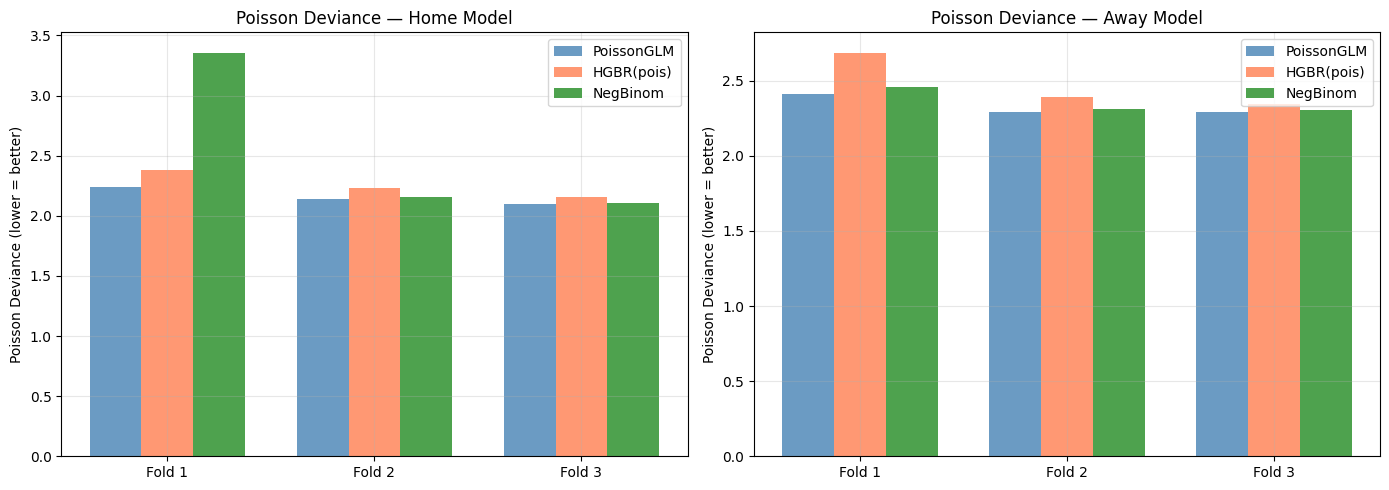

In [25]:
# Visualize fold-by-fold deviance across all 3 models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds  = [f['fold'] for f in glm_cv['fold_results']]
x      = np.arange(len(folds))
width  = 0.25

for ax, key_h, key_a, title in [
    (axes[0], 'dev_home', 'dev_home', 'Poisson Deviance — Home Model'),
    (axes[1], 'dev_away', 'dev_away', 'Poisson Deviance — Away Model'),
]:
    glm_vals = [f[key_h] for f in glm_cv['fold_results']]
    gbr_vals = [f[key_h] for f in gbr_cv['fold_results']]
    nb_vals  = [f[key_h] for f in nb_cv['fold_results']]

    ax.bar(x - width, glm_vals, width, label='PoissonGLM', color='steelblue', alpha=0.8)
    ax.bar(x,          gbr_vals, width, label='HGBR(pois)', color='coral',     alpha=0.8)
    ax.bar(x + width,  nb_vals,  width, label='NegBinom',   color='forestgreen', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i}' for i in folds])
    ax.set_ylabel('Poisson Deviance (lower = better)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### 8d. P(over) Calibration Curves — All Three Models

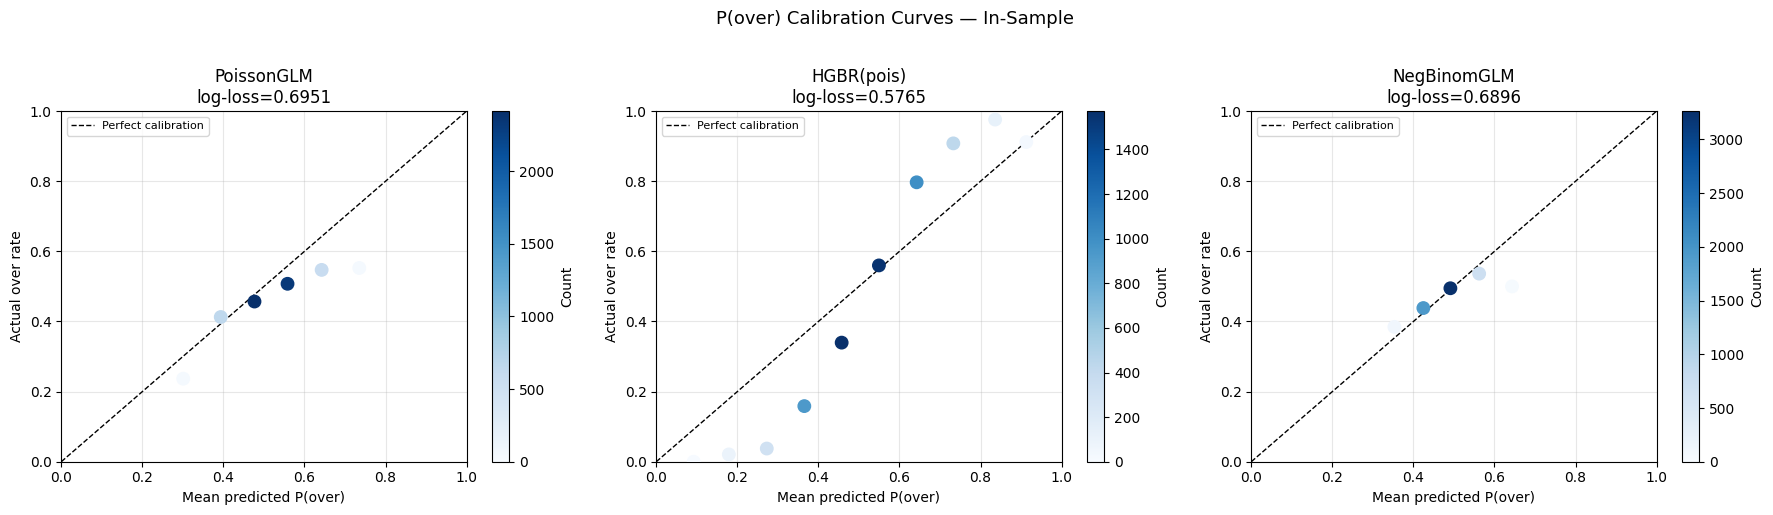

In [26]:
# Calibration curves: predicted P(over) vs actual over rate
# Uses in-sample predictions (same lam_h / lam_a for GLM)
# For a clean comparison: all three use the same feature predictions but
# GLM uses Poisson convolution, NegBinom uses NegBinom convolution, HGBR uses Poisson.

def calibration_curve_custom(probs, actuals, n_bins=10):
    bins = np.linspace(probs.min(), probs.max(), n_bins + 1)
    idx  = np.clip(np.digitize(probs, bins) - 1, 0, n_bins - 1)
    mean_pred, mean_actual, counts = [], [], []
    for i in range(n_bins):
        m = idx == i
        if m.sum() >= 10:
            mean_pred.append(probs[m].mean())
            mean_actual.append(actuals[m].mean())
            counts.append(m.sum())
    return np.array(mean_pred), np.array(mean_actual), np.array(counts)

# HGBR P(over) — use gbr_lam_h / gbr_lam_a from Section 5 if available
try:
    gbr_over_sub = np.array([
        p_over_poisson(float(h), float(a), float(l))
        for h, a, l in zip(gbr_lam_h[row_idx], gbr_lam_a[row_idx], lines_sub)
    ])
except NameError:
    print('gbr_lam_h not in scope — skipping HGBR calibration curve')
    gbr_over_sub = np.full(len(poisson_over), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    ('PoissonGLM', poisson_over[valid_rows],  'steelblue'),
    ('HGBR(pois)', gbr_over_sub[valid_rows],  'coral'),
    ('NegBinomGLM', nb_over_conv[valid_rows], 'forestgreen'),
]

for ax, (label, probs, color) in zip(axes, configs):
    valid = ~np.isnan(probs) & ~np.isnan(actual_over_sub[valid_rows])
    if valid.sum() < 20:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(label)
        continue
    mp, ma, cnt = calibration_curve_custom(probs[valid], actual_over_sub[valid_rows][valid])
    scatter = ax.scatter(mp, ma, c=cnt, cmap='Blues', s=80, zorder=5,
                         vmin=0, vmax=cnt.max())
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted P(over)')
    ax.set_ylabel('Actual over rate')
    ll = log_loss(actual_over_sub[valid_rows][valid], probs[valid])
    ax.set_title(f'{label}\nlog-loss={ll:.4f}')
    ax.legend(fontsize=8)
    plt.colorbar(scatter, ax=ax, label='Count')

plt.suptitle('P(over) Calibration Curves — In-Sample', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 8e. Updated Model Selection Decision

In [27]:
print('=' * 70)
print('UPDATED MODEL SELECTION DECISION (incorporating NegBinom)')
print('=' * 70)
print()
print('Walk-forward OOF Deviance (lower = better):')
print(f'  PoissonGLM:   home={glm_s["mean_dev_home"]:.4f}  away={glm_s["mean_dev_away"]:.4f}')
print(f'  HGBR(pois):   home={gbr_s["mean_dev_home"]:.4f}  away={gbr_s["mean_dev_away"]:.4f}')
print(f'  NegBinomGLM:  home={nb_s["mean_dev_home"]:.4f}  away={nb_s["mean_dev_away"]:.4f}')
print()
print('P(over) Log-loss (in-sample, lower = better):')
print(f'  Poisson conv:  {ll_poisson:.4f}')
print(f'  NegBinom conv: {ll_nb_conv:.4f}  (Δ={ll_nb_conv - ll_poisson:+.4f})')
print()
print('DECISION RULES:')
print()

# Rule 1: Which model predicts μ best?
best_mu_model = min(
    [('PoissonGLM', glm_s['mean_dev_home']),
     ('HGBR(pois)', gbr_s['mean_dev_home']),
     ('NegBinomGLM', nb_s['mean_dev_home'])],
    key=lambda x: x[1]
)[0]
print(f'1. Best μ prediction (lowest home deviance): {best_mu_model}')
print()

# Rule 2: NegBinom convolution
nb_wins_conv = ll_nb_conv < ll_poisson
print(f'2. NegBinom convolution improves log-loss: {nb_wins_conv}')
print(f'   → {"USE NegBinom convolution for P(over)" if nb_wins_conv else "Poisson convolution is sufficient"}')
print()

print('RECOMMENDATION:')
print()
if best_mu_model == 'NegBinomGLM' and nb_wins_conv:
    print('  ✓ Full NegBinom GLM: best μ AND best convolution')
    print('    Production model: NegBinomGLMWrapper → p_over_negbinom()')
    winner = 'negbinom'
elif nb_wins_conv:
    print(f'  ✓ Hybrid: {best_mu_model} for μ prediction + NegBinom convolution for P(over)')
    print(f'    Fit {best_mu_model} → get λ → p_over_negbinom(λ_h, λ_a, alpha, line)')
    winner = best_mu_model.lower().replace('(pois)', '').replace(' ', '')
else:
    print(f'  ✓ {best_mu_model} + Poisson convolution (NegBinom convolution did not help)')
    winner = best_mu_model.lower().replace('(pois)', '').replace(' ', '')

print()
print(f'SELECTED FOR NOTEBOOK 5 (Betting Simulation): {winner.upper()}')
print()
print('Alpha estimates for production NegBinom convolution:')
print(f'  alpha_home = {alpha_home_full:.4f}')
print(f'  alpha_away = {alpha_away_full:.4f}')
print('  Note: re-estimate alpha on each training set in live pipeline')

UPDATED MODEL SELECTION DECISION (incorporating NegBinom)

Walk-forward OOF Deviance (lower = better):
  PoissonGLM:   home=2.1615  away=2.3302
  HGBR(pois):   home=2.2587  away=2.4734
  NegBinomGLM:  home=2.5389  away=2.3586

P(over) Log-loss (in-sample, lower = better):
  Poisson conv:  0.6951
  NegBinom conv: 0.6896  (Δ=-0.0055)

DECISION RULES:

1. Best μ prediction (lowest home deviance): PoissonGLM

2. NegBinom convolution improves log-loss: True
   → USE NegBinom convolution for P(over)

RECOMMENDATION:

  ✓ Hybrid: PoissonGLM for μ prediction + NegBinom convolution for P(over)
    Fit PoissonGLM → get λ → p_over_negbinom(λ_h, λ_a, alpha, line)

SELECTED FOR NOTEBOOK 5 (Betting Simulation): POISSONGLM

Alpha estimates for production NegBinom convolution:
  alpha_home = 0.2538
  alpha_away = 0.3002
  Note: re-estimate alpha on each training set in live pipeline


In [28]:
import joblib
from pathlib import Path
from datetime import datetime

# Fit NegBinom on full dataset for saving
print('Fitting NegBinom GLM on full dataset for artefact...')
nb_h_final = make_negbinom_glm(alpha=alpha_home_full)
nb_a_final = make_negbinom_glm(alpha=alpha_away_full)
nb_h_final.fit(X, y_home)
nb_a_final.fit(X, y_away)

artefact_nb = {
    'model_home': nb_h_final,
    'model_away': nb_a_final,
    'model_type': 'negbinom',
    'feature_names': list(X.columns),
    'alpha_home': alpha_home_full,
    'alpha_away': alpha_away_full,
    'trained_seasons': '2022-2024',
    'mean_dev_home_oof': nb_s['mean_dev_home'],
    'mean_dev_away_oof': nb_s['mean_dev_away'],
    'mean_d2_home_oof': nb_s['mean_d2_home'],
    'mean_d2_away_oof': nb_s['mean_d2_away'],
    'version': '1.0.0',
    'trained_at': datetime.now().isoformat(),
}

Path('data/models').mkdir(parents=True, exist_ok=True)
joblib.dump(artefact_nb, 'data/models/negbinom_glm_v1.0.0.pkl')
print('Saved → data/models/negbinom_glm_v1.0.0.pkl')
print()
print('Notebook 4 complete.')
print('Next: Notebook 5 — Betting Simulation using selected model + NegBinom convolution.')

Fitting NegBinom GLM on full dataset for artefact...
Saved → data/models/negbinom_glm_v1.0.0.pkl

Notebook 4 complete.
Next: Notebook 5 — Betting Simulation using selected model + NegBinom convolution.
